# Spotify Data Analysis with Python (Pandas)

Author: Kehinde Onifade  
Tools: Python, Pandas  

## Introduction

This project analyzes Spotify song data using Python (pandas).

The goal is to explore trends in:
- Song releases over time
- Artist productivity
- Genre distribution
- Song duration patterns

## Data Loading

In [3]:
import pandas as pd

df = pd.read_csv("spotify.xlsx.csv")
df.head()

,title,artist,top genre,year released,added,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop,top year,artist type
0,STARSTRUKK (feat. Katy Perry),3OH!3,dance pop,2009,2022/02/17,140,81,61,-6,23,23,203,0,6,70,2010,Duo
1,My First Kiss (feat. Ke$ha),3OH!3,dance pop,2010,2022/02/17,138,89,68,-4,36,83,192,1,8,68,2010,Duo
2,I Need A Dollar,Aloe Blacc,pop soul,2010,2022/02/17,95,48,84,-7,9,96,243,20,3,72,2010,Solo
3,Airplanes (feat. Hayley Williams of Paramore),B.o.B,atl hip hop,2010,2022/02/17,93,87,66,-4,4,38,180,11,12,80,2010,Solo
4,Nothin' on You (feat. Bruno Mars),B.o.B,atl hip hop,2010,2022/02/17,104,85,69,-6,9,74,268,39,5,79,2010,Solo


## Data Cleaning

In [4]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   title          1000 non-null   str  
 1   artist         1000 non-null   str  
 2   top genre      1000 non-null   str  
 3   year released  1000 non-null   int64
 4   added          1000 non-null   str  
 5   bpm            1000 non-null   int64
 6   nrgy           1000 non-null   int64
 7   dnce           1000 non-null   int64
 8   dB             1000 non-null   int64
 9   live           1000 non-null   int64
 10  val            1000 non-null   int64
 11  dur            1000 non-null   int64
 12  acous          1000 non-null   int64
 13  spch           1000 non-null   int64
 14  pop            1000 non-null   int64
 15  top year       1000 non-null   int64
 16  artist type    1000 non-null   str  
dtypes: int64(12), str(5)
memory usage: 132.9 KB


title            0
artist           0
top genre        0
year released    0
added            0
bpm              0
nrgy             0
dnce             0
dB               0
live             0
val              0
dur              0
acous            0
spch             0
pop              0
top year         0
artist type      0
dtype: int64

## March Upload Analysis

This calculates the number of records where the 'added' date falls in March.

In [8]:
import pandas as pd

df = pd.read_csv("spotify.xlsx.csv")

# Convert 'added' column to date
df["added"] = pd.to_datetime(df["added"])

# Count records in March
march_count = (df["added"].dt.month == 3).sum()

march_count

print("Number of records added in March:", march_count)


Number of records added in March: 3


## Duration Analysis

This groups the data by year and finds the maximum song duration for each year.

In [9]:
import pandas as pd

df = pd.read_csv("spotify.xlsx.csv")

result_q2 = df.groupby("year released")["dur"].max().reset_index()

result_q2

,year released,dur
0,1975,354
1,2009,321
2,2010,308
3,2011,337
4,2012,350
5,2013,688
6,2014,323
7,2015,296
8,2016,348
9,2017,343


## Artist Productivity

In [10]:
import pandas as pd

df = pd.read_csv("spotify.xlsx.csv")

result_q3 = (
    df.groupby("artist")
      .size()
      .reset_index(name="number_of_songs")
      .sort_values(by="number_of_songs", ascending=False)
)

result_q3

,artist,number_of_songs
383,Taylor Swift,21
106,Drake,18
65,Calvin Harris,18
333,Rihanna,14
24,Ariana Grande,14
...,...,...
403,Tom Odell,1
406,Travie McCoy,1
409,Troye Sivan,1
410,Twenty One Pilots,1


## Songs in 2010

In [11]:
import pandas as pd

df = pd.read_csv("spotify.xlsx.csv")

result_q4 = (
    df[df["year released"] == 2010]
      .groupby("artist")
      .size()
      .reset_index(name="songs_in_2010")
      .sort_values(by="songs_in_2010", ascending=False)
)

result_q4

,artist,songs_in_2010
28,Kesha,6
4,Bruno Mars,5
39,Rihanna,5
56,Usher,4
22,Jason Derulo,3
2,B.o.B,3
12,Edward Maya,2
3,Black Eyed Peas,2
14,Ellie Goulding,2
18,Far East Movement,2


## Genre Trends

In [12]:
result_q5 = (
    df.groupby(["top genre", "year released"])
      .size()
      .reset_index(name="number_of_songs")
      .sort_values(by=["year released", "number_of_songs"], ascending=[True, False])
)
result_q5

,top genre,year released,number_of_songs
131,classic rock,1975,1
153,dance pop,2009,10
23,art pop,2009,3
57,barbadian pop,2009,2
69,big room,2009,2
...,...,...,...
50,australian dance,2020,1
86,boy band,2020,1
10,alt z,2021,1
34,art pop,2021,1


## Top 10 longest songs

This analysis identifies the songs with the highest duration values.
It helps highlight unusually long tracks and understand duration patterns in the dataset.

In [ ]:
top_longest = df.sort_values(by="dur", ascending=False).head(10)
top_longest

,title,artist,top genre,year released,added,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop,top year,artist type
443,Not a Bad Thing,Justin Timberlake,dance pop,2013,2020/06/10,86,56,31,-9,13,11,688,53,7,61,2014,Solo
350,Mirrors,Justin Timberlake,dance pop,2013,2020/06/11,77,51,57,-7,9,51,484,23,5,83,2013,Solo
873,Te Boté - Remix,Nio Garcia,latin,2018,2020/06/22,97,68,90,-3,6,44,418,54,21,81,2018,Solo
982,Bohemian Rhapsody - Remastered 2011,Queen,classic rock,1975,2020/06/22,144,40,39,-10,24,23,354,29,5,77,2019,Band/Group
329,Lose Yourself to Dance (feat. Pharrell Williams),Daft Punk,electro,2013,2020/06/11,100,66,83,-8,8,67,354,8,6,74,2013,Duo
248,m.A.A.d city,Kendrick Lamar,conscious hip hop,2012,2020/06/22,91,73,49,-7,44,22,350,5,27,73,2012,Solo
686,Somebody Else,The 1975,modern alternative rock,2016,2020/06/08,101,79,61,-6,15,47,348,20,6,76,2016,Band/Group
764,Bad and Boujee (feat. Lil Uzi Vert),Migos,atl hip hop,2017,2021/01/28,127,67,93,-5,12,17,343,6,24,78,2017,Trio
347,Holy Grail,JAY-Z,east coast hip hop,2013,2020/06/11,145,53,68,-7,26,16,338,6,8,68,2013,Solo
110,Holocene,Bon Iver,eau claire indie,2011,2020/06/16,148,30,37,-15,13,15,337,94,3,70,2011,Band/Group


## Most popular genres

This analysis shows the most frequent genres in the dataset.
It helps identify dominant music trends across all years.

In [14]:
top_genres = (
    df.groupby("top genre")
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

top_genres.head(10)

,top genre,count
51,dance pop,361
120,pop,57
14,atl hip hop,39
12,art pop,37
85,hip hop,21
30,boy band,21
36,canadian hip hop,18
68,edm,17
75,folk-pop,15
48,conscious hip hop,14


## Average Song Duration per Year

This analysis calculates the average duration of songs released each year to observe trends over time.

In [15]:
avg_duration = (
    df.groupby("year released")["dur"]
    .mean()
    .reset_index(name="avg_duration")
)

avg_duration

,year released,avg_duration
0,1975,354.000000
1,2009,240.000000
2,2010,221.968085
3,2011,231.010753
4,2012,227.825688
5,2013,234.965116
6,2014,222.099010
7,2015,219.939394
8,2016,221.290698
9,2017,216.818182


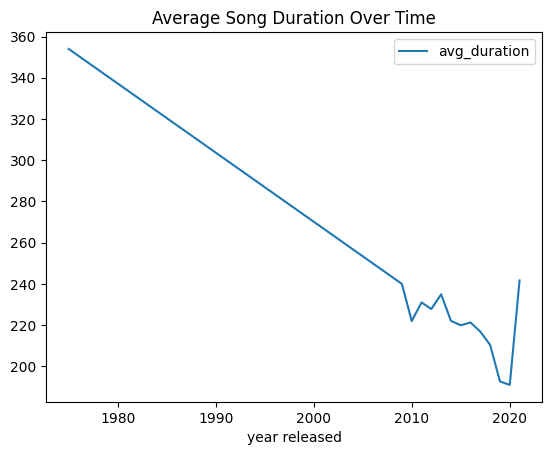

In [16]:
import matplotlib.pyplot as plt

avg_duration.plot(x="year released", y="avg_duration", kind="line")
plt.title("Average Song Duration Over Time")
plt.show()